# Centralized Export Operating Envelope Scenario Study


- Target node: **Node 11**
- DER nodes: **Nodes 3, 9, and 11**
- Scenario source: **NASA POWER hourly irradiance data**
- Number of selected scenarios: **100**
- Thermal constraint: **disabled**
- Reactive support: **disabled**


## Model overview

For each scenario, the OPF maximizes the export from the target node.
subject to:

- linearized DistFlow power balance,
- nodal voltage limits,
- PV availability in the current scenario,
- optional thermal limits,
- optional inverter reactive support.

The key output columns are:

- `export_OE_MW`: maximum feasible active export from the target node,
- `local_voltage_pu`: local voltage at the target node under the OE solution,
- `pv_available_binding`: whether the OE equals the available PV power,
- `voltage_upper_binding`: whether any node reaches the upper voltage limit.


In [1]:
import os
import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1. Imports and user settings

In [2]:
# ============================================================
# 0. User settings

In [3]:
# ============================================================

NASA_FILE = "POWER_Point_Hourly_20250601_20250831_045d51N_073d59W_LST.csv"
OUTPUT_DIR = "results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

N_SCENARIOS = 100
RANDOM_SEED = 10

TARGET_NODE = 11
DER_NODES = [3, 9, 11]

USE_THERMAL_CONSTRAINT = False
USE_REACTIVE_SUPPORT = False

## 2. Original feeder data

In [4]:
# ============================================================
# 1. Original network data

In [5]:
# ============================================================

N = 13
slack = 0

base_l_P = np.array([
    0, 0.2, 0, 0.4, 0.17, 0.23, 1.155,
    0, 0.17, 0.843, 0, 0.17, 0.128
])

base_l_Q = np.array([
    0, 0.116, 0, 0.29, 0.125, 0.132,
    0.66, 0, 0.151, 0.462, 0, 0.08, 0.086
])

v_min = 0.95
v_max = 1.05

r = np.array([
[0, 0.007547918, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0.0041, 0, 0.007239685, 0, 0.007547918, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0.004343811, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0.003773959, 0, 0, 0.004322245, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0.00434686, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.004343157, 0.01169764],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

x = np.array([
[0, 0.022173236, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0.0064, 0, 0.007336076, 0, 0.022173236, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0.004401645, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0.011086618, 0, 0, 0.004433667, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0.002430473, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.004402952, 0.004490848],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])



I_max = np.array([
[0, 3.0441, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 1.4178, 0, 0.9591, 0, 3.0441, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 3.1275, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0.9591, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 3.0441, 3.1275, 0, 0.9591, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1.37193, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.9591, 1.2927],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

A = np.array([
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

edges = [(i, j) for i in range(N) for j in range(N) if A[i, j] == 1]

## 3. PV configuration

In [6]:
# ============================================================
# 2. PV configuration

In [7]:
# ============================================================

pv_capacity = np.zeros(N)

pv_capacity[3] = 3.0
pv_capacity[9] = 4.0
pv_capacity[11] = 6.0

## 4. NASA POWER scenario data

In [8]:
# ============================================================
# 3. NASA POWER data

In [9]:
# ============================================================

def load_nasa_power_hourly(filepath, n_scenarios=100, seed=10):

    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()

    header_row = None

    for i, line in enumerate(lines):
        if line.startswith("YEAR,MO,DY,HR"):
            header_row = i
            break

    if header_row is None:
        raise ValueError("Cannot find NASA POWER data header row.")

    raw = pd.read_csv(filepath, skiprows=header_row)
    raw.columns = [str(c).strip() for c in raw.columns]

    required = ["YEAR", "MO", "DY", "HR"]
    for col in required:
        if col not in raw.columns:
            raise ValueError(f"Missing column: {col}")

    solar_cols = [c for c in raw.columns if c.startswith("ALLSKY")]
    if len(solar_cols) == 0:
        raise ValueError("Cannot find ALLSKY irradiance column.")

    solar_col = solar_cols[0]

    df = raw.copy()
    df = df[df[solar_col] > -100].copy()

    df["datetime"] = pd.to_datetime(
        dict(
            year=df["YEAR"].astype(int),
            month=df["MO"].astype(int),
            day=df["DY"].astype(int),
            hour=df["HR"].astype(int),
        )
    )

    df = df.rename(columns={solar_col: "irradiance_W_m2"})

    df = df[df["irradiance_W_m2"] > 50].copy()

    def classify_period(hour):
        if 6 <= hour <= 10:
            return "morning"
        elif 11 <= hour <= 14:
            return "noon"
        elif 15 <= hour <= 19:
            return "evening"
        else:
            return "other"

    df["time_period"] = df["HR"].apply(classify_period)
    df = df[df["time_period"] != "other"].copy()

    hourly_load_factor = {
        6: 0.65,
        7: 0.75,
        8: 0.85,
        9: 0.90,
        10: 0.85,
        11: 0.75,
        12: 0.70,
        13: 0.68,
        14: 0.70,
        15: 0.78,
        16: 0.90,
        17: 1.05,
        18: 1.20,
        19: 1.25,
    }

    df["load_factor"] = df["HR"].map(hourly_load_factor)

    rng = np.random.default_rng(seed)
    df["load_factor"] = df["load_factor"] * rng.normal(
        loc=1.0,
        scale=0.08,
        size=len(df)
    )

    df["load_factor"] = df["load_factor"].clip(0.5, 1.4)

    if len(df) > n_scenarios:
        df = df.sample(n=n_scenarios, random_state=seed).copy()

    df = df.sort_values("datetime").reset_index(drop=True)
    df["scenario"] = np.arange(len(df))

    return df

## 5. Centralized export OE model

In [10]:
# ============================================================
# 4. Centralized export OE model

In [11]:
# ============================================================

def solve_centralized_export_OE(
    target_node,
    l_P,
    l_Q,
    pv_forecast,
    verbose=False,
):

    P = cp.Variable((N, N))
    Q = cp.Variable((N, N))
    v = cp.Variable(N)

    export = cp.Variable(nonneg=True)
    q_pv = cp.Variable(N)

    constraints = [
        v[slack] == 1.0,
        v >= v_min ** 2,
        v <= v_max ** 2,

        # Current-scenario available PV limit.
        export <= pv_forecast[target_node],
    ]

    for j in range(N):
        if j not in DER_NODES:
            constraints += [q_pv[j] == 0]

    if USE_REACTIVE_SUPPORT:
        for j in DER_NODES:
            constraints += [
                q_pv[j] >= -pv_capacity[j] * 0.3,
                q_pv[j] <= pv_capacity[j] * 0.3,
            ]

            if j == target_node:
                constraints += [
                    cp.norm(cp.hstack([export, q_pv[j]]), 2)
                    <= pv_capacity[j]
                ]
            else:
                constraints += [
                    cp.norm(cp.hstack([pv_forecast[j], q_pv[j]]), 2)
                    <= pv_capacity[j]
                ]
    else:
        constraints += [q_pv == 0]

    edge_set = set(edges)

    for i in range(N):
        for j in range(N):
            if (i, j) not in edge_set:
                constraints += [
                    P[i, j] == 0,
                    Q[i, j] == 0,
                ]

    children = {i: [] for i in range(N)}
    parent = {}

    for i, j in edges:
        children[i].append(j)
        parent[j] = i

    for j in range(1, N):

        i = parent[j]

        downstream_P = cp.sum([
            P[j, k]
            for k in children[j]
        ])

        downstream_Q = cp.sum([
            Q[j, k]
            for k in children[j]
        ])

        if j == target_node:
            net_P = l_P[j] - export
        else:
            net_P = l_P[j] - pv_forecast[j]

        net_Q = l_Q[j] - q_pv[j]

        constraints += [
            P[i, j] == net_P + downstream_P,
            Q[i, j] == net_Q + downstream_Q,
            v[j] == v[i] - 2.0 * (
                r[i, j] * P[i, j]
                + x[i, j] * Q[i, j]
            ),
        ]

        if USE_THERMAL_CONSTRAINT:
            constraints += [
                cp.norm(
                    cp.hstack([P[i, j], Q[i, j]]),
                    2
                ) <= I_max[i, j]
            ]

    problem = cp.Problem(
        cp.Maximize(export),
        constraints
    )

    try:
        problem.solve(solver=cp.CLARABEL, verbose=verbose)
    except Exception:
        problem.solve(solver=cp.SCS, verbose=verbose)

    if problem.status not in ["optimal", "optimal_inaccurate"]:
        return {
            "export_OE": np.nan,
            "local_voltage": np.nan,
            "status": problem.status,
            "voltage_upper_binding": False,
            "voltage_lower_binding": False,
            "thermal_binding": False,
            "q_pv": np.full(N, np.nan),
        }

    voltage = np.sqrt(np.maximum(v.value, 0))
    local_voltage = float(voltage[target_node])
    export_OE = float(export.value)

    voltage_upper_binding = bool(np.any(np.abs(voltage - v_max) < 1e-3))
    voltage_lower_binding = bool(np.any(np.abs(voltage - v_min) < 1e-3))

    thermal_binding = False

    if USE_THERMAL_CONSTRAINT:

        for i, j in edges:

           apparent = np.sqrt(
                 P.value[i, j] ** 2
                 + Q.value[i, j] ** 2
           )

        # Only check existing lines with positive ratings
           if (
                I_max[i, j] > 0
                and np.isclose(apparent, I_max[i, j], atol=1e-3)
           ):
                thermal_binding = True
                break

    return {
        "export_OE": export_OE,
        "local_voltage": local_voltage,
        "status": problem.status,
        "voltage_upper_binding": voltage_upper_binding,
        "voltage_lower_binding": voltage_lower_binding,
        "thermal_binding": thermal_binding,
        "q_pv": np.array(q_pv.value).astype(float),
    }

## 6. Run scenario study

In [12]:
# ============================================================
# 5. Run scenario study

In [13]:
# ============================================================

scenario_df = load_nasa_power_hourly(
    NASA_FILE,
    n_scenarios=N_SCENARIOS,
    seed=RANDOM_SEED,
)

results = []

for _, row in scenario_df.iterrows():

    scenario = int(row["scenario"])
    irradiance = float(row["irradiance_W_m2"])
    load_factor = float(row["load_factor"])

    l_P_s = base_l_P * load_factor
    l_Q_s = base_l_Q * load_factor

    pv_forecast = np.zeros(N)

    for der_node in DER_NODES:
        pv_forecast[der_node] = (
            pv_capacity[der_node]
            * irradiance
            / 1000.0
        )

    result = solve_centralized_export_OE(
        target_node=TARGET_NODE,
        l_P=l_P_s,
        l_Q=l_Q_s,
        pv_forecast=pv_forecast,
    )

    q_pv_value = result["q_pv"]

    results.append({
        "scenario": scenario,
        "datetime": row["datetime"],
        "month": int(row["MO"]),
        "day": int(row["DY"]),
        "hour": int(row["HR"]),
        "time_period": row["time_period"],

        "target_node": TARGET_NODE,
        "der_nodes": str(DER_NODES),

        "irradiance_W_m2": irradiance,
        "load_factor": load_factor,

        "target_pv_capacity_MW": pv_capacity[TARGET_NODE],
        "target_pv_available_MW": pv_forecast[TARGET_NODE],

        "export_OE_MW": result["export_OE"],
        "local_voltage_pu": result["local_voltage"],

        "status": result["status"],

        "voltage_upper_binding": result["voltage_upper_binding"],
        "voltage_lower_binding": result["voltage_lower_binding"],
        "thermal_binding": result["thermal_binding"],

        "pv_forecast_node_3_MW": pv_forecast[3],
        "pv_forecast_node_9_MW": pv_forecast[9],
        "pv_forecast_node_11_MW": pv_forecast[11],

        "q_support_node_3_MVAr": q_pv_value[3],
        "q_support_node_9_MVAr": q_pv_value[9],
        "q_support_node_11_MVAr": q_pv_value[11],
    })

results_df = pd.DataFrame(results)

results_df["pv_available_binding"] = np.isclose(
    results_df["export_OE_MW"],
    results_df["target_pv_available_MW"],
    atol=1e-4,
)

plot_df = results_df[
    results_df["status"].isin(["optimal", "optimal_inaccurate"])
].copy()

## 7. Save and print outputs

In [14]:
# ============================================================
# 6. Save and print outputs

In [15]:
# ============================================================

results_file = os.path.join(
    OUTPUT_DIR,
    f"centralized_export_OE_NASA_target_node_{TARGET_NODE}.csv"
)

summary_file = os.path.join(
    OUTPUT_DIR,
    f"summary_target_node_{TARGET_NODE}.csv"
)

results_df.to_csv(results_file, index=False)

summary = pd.DataFrame({
    "target_node": [TARGET_NODE],
    "number_of_scenarios": [len(results_df)],
    "optimal_cases": [len(plot_df)],
    "infeasible_cases": [len(results_df) - len(plot_df)],

    "mean_export_OE_MW": [plot_df["export_OE_MW"].mean()],
    "min_export_OE_MW": [plot_df["export_OE_MW"].min()],
    "max_export_OE_MW": [plot_df["export_OE_MW"].max()],

    "mean_voltage_pu": [plot_df["local_voltage_pu"].mean()],
    "min_voltage_pu": [plot_df["local_voltage_pu"].min()],
    "max_voltage_pu": [plot_df["local_voltage_pu"].max()],

    "pv_available_binding_count": [plot_df["pv_available_binding"].sum()],
    "voltage_upper_binding_count": [plot_df["voltage_upper_binding"].sum()],
    "voltage_lower_binding_count": [plot_df["voltage_lower_binding"].sum()],
    "thermal_binding_count": [plot_df["thermal_binding"].sum()],
})

summary.to_csv(summary_file, index=False)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("\nNASA-based centralized export OE results")
print("----------------------------------------")
print(f"Target node: {TARGET_NODE}")
print(f"DER nodes: {DER_NODES}")
print(f"Reactive support enabled: {USE_REACTIVE_SUPPORT}")
print()
print(results_df.head(20))

print("\nRows:", len(results_df))
print("Optimal cases:", len(plot_df))
print("Infeasible cases:", len(results_df) - len(plot_df))

print("\nBinding summary")
print("----------------")
print(
    plot_df[
        [
            "voltage_upper_binding",
            "voltage_lower_binding",
            "thermal_binding",
            "pv_available_binding",
        ]
    ].sum()
)

print("\nSummary")
print("-------")
print(summary)

print("\nCorrelation between Export OE and Local Voltage")
print("-----------------------------------------------")
print(
    plot_df[
        [
            "export_OE_MW",
            "local_voltage_pu",
        ]
    ].corr()
)

print("\nSaved files:")
print(f"- {results_file}")
print(f"- {summary_file}")


NASA-based centralized export OE results
----------------------------------------
Target node: 11
DER nodes: [3, 9, 11]
Reactive support enabled: False

    scenario            datetime  month  day  hour time_period  target_node   der_nodes  irradiance_W_m2  load_factor  target_pv_capacity_MW  target_pv_available_MW  export_OE_MW  local_voltage_pu  \
0          0 2025-06-01 13:00:00      6    1    13        noon           11  [3, 9, 11]           241.82     0.726672                    6.0                 1.45092      1.450920          0.961976   
1          1 2025-06-01 17:00:00      6    1    17     evening           11  [3, 9, 11]            83.50     0.981556                    6.0                 0.50100           NaN               NaN   
2          2 2025-06-02 16:00:00      6    2    16     evening           11  [3, 9, 11]           351.12     0.845235                    6.0                 2.10672      2.106720          0.971977   
3          3 2025-06-03 08:00:00      6    3  

## 8. Visualisations

In [16]:
# ============================================================
# 7. Plots

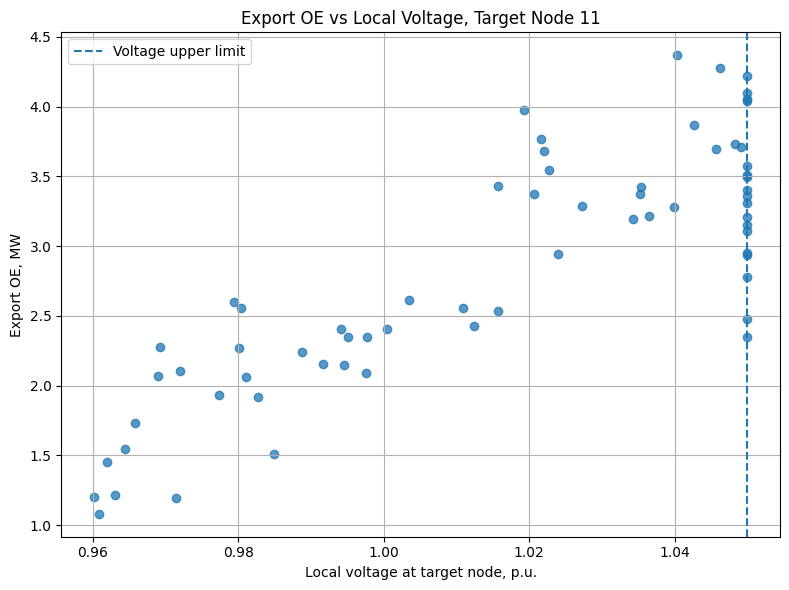

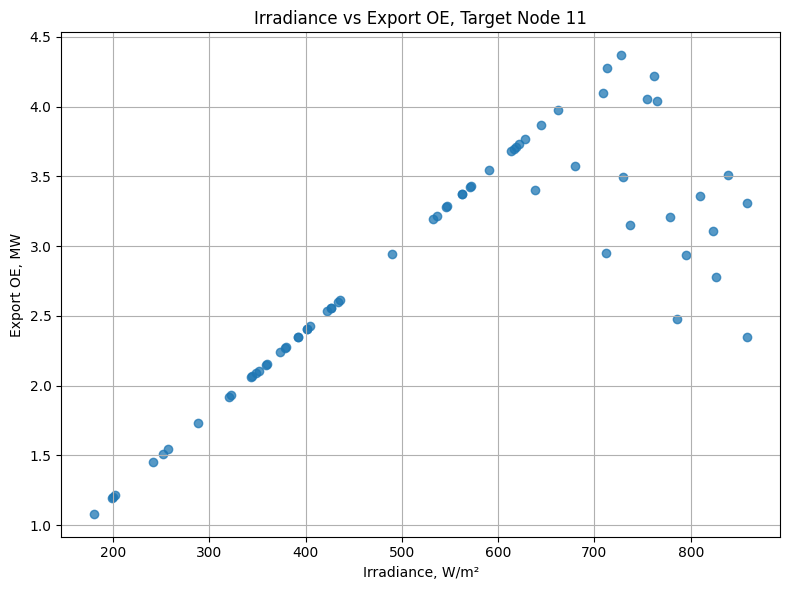

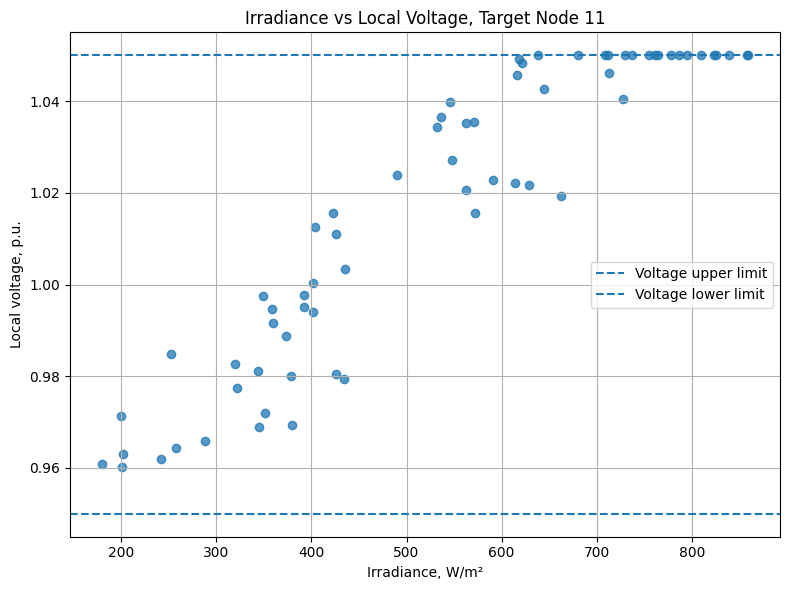

In [17]:
# ============================================================

plt.figure(figsize=(8, 6))
plt.scatter(
    plot_df["local_voltage_pu"],
    plot_df["export_OE_MW"],
    alpha=0.75,
)
plt.xlabel("Local voltage at target node, p.u.")
plt.ylabel("Export OE, MW")
plt.title(f"Export OE vs Local Voltage, Target Node {TARGET_NODE}")
plt.axvline(v_max, linestyle="--", label="Voltage upper limit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        f"plot_OE_vs_local_voltage_target_node_{TARGET_NODE}.png"
    ),
    dpi=300
)
plt.show()


plt.figure(figsize=(8, 6))
plt.scatter(
    plot_df["irradiance_W_m2"],
    plot_df["export_OE_MW"],
    alpha=0.75,
)
plt.xlabel("Irradiance, W/m²")
plt.ylabel("Export OE, MW")
plt.title(f"Irradiance vs Export OE, Target Node {TARGET_NODE}")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        f"plot_irradiance_vs_export_OE_target_node_{TARGET_NODE}.png"
    ),
    dpi=300
)
plt.show()


plt.figure(figsize=(8, 6))
plt.scatter(
    plot_df["irradiance_W_m2"],
    plot_df["local_voltage_pu"],
    alpha=0.75,
)
plt.xlabel("Irradiance, W/m²")
plt.ylabel("Local voltage, p.u.")
plt.title(f"Irradiance vs Local Voltage, Target Node {TARGET_NODE}")
plt.axhline(v_max, linestyle="--", label="Voltage upper limit")
plt.axhline(v_min, linestyle="--", label="Voltage lower limit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        f"plot_irradiance_vs_local_voltage_target_node_{TARGET_NODE}.png"
    ),
    dpi=300
)
plt.show()